# TD3 — Climate Projections: Comparing Warming Scenarios

**Context:** Climate models produce projections for different emission scenarios, called **RCPs** (Representative Concentration Pathways). In this TD we will work with three:

| Scenario | Description |
|----------|-------------|
| **RCP 2.6** | Strong mitigation — warming below +2°C by 2100 |
| **RCP 4.5** | Moderate mitigation — warming around +2-3°C |
| **RCP 8.5** | Business as usual — warming above +4°C by 2100 |

We also have a **historical** dataset (1951-2005) to use as a reference.

The data comes from **DRIAS-2020**, a French climate service. It uses the model **CNRM-ALADIN63** driven by **CNRM-CM5**, bias-corrected with the **ADAMONT-SAFRAN** method, for a single grid point near **Paris** (48.9 N, 2.4 E).

Variables available:
- `tasmin` - daily minimum temperature (in Kelvin in the raw file)
- `tasmax` - daily maximum temperature (in Kelvin)
- `tas`    - daily mean temperature (in Kelvin)
- `prtot`  - total precipitation (in kg/m2/s)
- `prsn`   - solid precipitation (in kg/m2/s)


---
## Part 1 - Loading the Data

The data is stored as CSV files in the `data/` folder. Each file corresponds
to one scenario and contains daily climate data for a point near Paris.

We load them with `pd.read_csv()`, which we already know from TD2:

```python
df = pd.read_csv("data/my_file.csv")
```

The columns are already named: `date`, `lat`, `lon`, `tasmin`, `tasmax`, `tas`, `prtot`, `prsn`.


### 1.1 - Import the necessary libraries

Import the pandas library (most useful library when we want to analyze dataframes)

In [ ]:
import pandas as pd 



### 1.2 - Load the historical dataset

Write the path of the historical file (it's the txt file with historical within its name), don't forget to separate folder to files with `\`. 


In [2]:
hist_csv = "data/tasmintasmaxtasprtotprsn_France_CNRM-CERFACS-CNRM-CM5_historical_r1i1p1_CNRM-ALADIN63_v2_MF-ADAMONT-SAFRAN-1980-2011_day_19510101-20051231.csv"

df_hist = pd.read_csv(hist_csv)

print(df_hist.head())
print(df_hist.shape)


       date      lat      lon  tasmin  tasmax     tas     prtot      prsn
0  19510101  48.8954  2.39172  271.17  274.39  272.45  0.000016  0.000015
1  19510102  48.8954  2.39172  270.39  273.18  272.01  0.000000  0.000000
2  19510103  48.8954  2.39172  270.71  273.29  272.22  0.000000  0.000000
3  19510104  48.8954  2.39172  271.19  272.40  271.63  0.000000  0.000000
4  19510105  48.8954  2.39172  270.60  272.49  271.83  0.000000  0.000000
(20089, 8)


Load the dataframe with the function from `pandas` `read_csv`, use the argument `comment=...` specifying how the commented lines are marked.

### 1.3 - Load the three projection datasets

Do the same for the three RCP scenarios. The file names follow the same pattern but contain `rcp26`, `rcp45`, or `rcp85` instead of `historical`.


In [4]:
rcp26_csv = "data/tasmintasmaxtasprtotprsn_France_CNRM-CERFACS-CNRM-CM5_rcp26_r1i1p1_CNRM-ALADIN63_v2_MF-ADAMONT-SAFRAN-1980-2011_day_20060101-21001231.csv"
rcp45_csv = "data/tasmintasmaxtasprtotprsn_France_CNRM-CERFACS-CNRM-CM5_rcp45_r1i1p1_CNRM-ALADIN63_v2_MF-ADAMONT-SAFRAN-1980-2011_day_20060101-21001231.csv"
rcp85_csv = "data/tasmintasmaxtasprtotprsn_France_CNRM-CERFACS-CNRM-CM5_rcp85_r1i1p1_CNRM-ALADIN63_v2_MF-ADAMONT-SAFRAN-1980-2011_day_20060101-21001231.csv"

df_rcp26 = pd.read_csv(rcp26_csv)
df_rcp45 = pd.read_csv(rcp45_csv)
df_rcp85 = pd.read_csv(rcp85_csv)

print("rcp26:", df_rcp26.shape, "| rcp45:", df_rcp45.shape, "| rcp85:", df_rcp85.shape)


rcp26: (34698, 8) | rcp45: (34698, 8) | rcp85: (34698, 8)


---
## Part 2 - Cleaning and Converting Units

### 2.1 - Parse dates

The `date` column currently contains integers like `19510101`.
Convert it to a proper date with `pd.to_datetime(df["date"], format="%Y%m%d")`.
Do this for all four dataframes.


In [5]:
for df in [df_hist, df_rcp26, df_rcp45, df_rcp85]:
    df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

print(df_hist["date"].dtype)
print(df_hist["date"].head())


datetime64[ns]
0   1951-01-01
1   1951-01-02
2   1951-01-03
3   1951-01-04
4   1951-01-05
Name: date, dtype: datetime64[ns]


### 2.2 - Convert temperature from Kelvin to Celsius

The raw data is in **Kelvin** (K). Subtract 273.15 to get **Celsius** (degC).

Create columns `tasmin_c`, `tasmax_c`, `tas_c` for all four dataframes.

Question: What is the historical average temperature in degC? Is it consistent with what you know about Paris?


In [6]:
for df in [df_hist, df_rcp26, df_rcp45, df_rcp85]:
    df["tasmin_c"] = df["tasmin"] - 273.15
    df["tasmax_c"] = df["tasmax"] - 273.15
    df["tas_c"]    = df["tas"]    - 273.15

print("Historical mean temperature:", df_hist["tas_c"].mean().round(2), "degC")


Historical mean temperature: 12.15 degC


### 2.3 - Convert precipitation from kg/m2/s to mm/day

Multiply by **86 400** (seconds per day) to get mm/day.

Create a column `precip_mm` for all four dataframes.


In [7]:
for df in [df_hist, df_rcp26, df_rcp45, df_rcp85]:
    df["precip_mm"] = df["prtot"] * 86400

print("Historical mean daily precipitation:", df_hist["precip_mm"].mean().round(2), "mm/day")


Historical mean daily precipitation: 1.67 mm/day


---
## Part 3 - Annual Temperature Trends

### 3.1 - Add a year column

Extract the year from the `date` column using `.dt.year` and store it in a new column `year`. Do this for all four dataframes.


In [8]:
for df in [df_hist, df_rcp26, df_rcp45, df_rcp85]:
    df["year"] = df["date"].dt.year


### 3.2 - Compute annual mean temperature per scenario

Use `groupby("year")["tas_c"].mean()` for each dataset and store the results.


In [9]:
annual_hist  = df_hist.groupby("year")["tas_c"].mean().reset_index()
annual_rcp26 = df_rcp26.groupby("year")["tas_c"].mean().reset_index()
annual_rcp45 = df_rcp45.groupby("year")["tas_c"].mean().reset_index()
annual_rcp85 = df_rcp85.groupby("year")["tas_c"].mean().reset_index()

print(annual_hist.tail())


    year      tas_c
50  2001  12.234301
51  2002  12.403370
52  2003  12.997836
53  2004  13.433333
54  2005  12.518658


### 3.3 - Plot all scenarios on a single chart

Call `plt.plot()` multiple times before `plt.show()` to overlay all scenarios.
Add a legend with `plt.legend()` and use different colours per scenario.

**Observation:** When do the scenarios start to diverge? What happens after 2050?


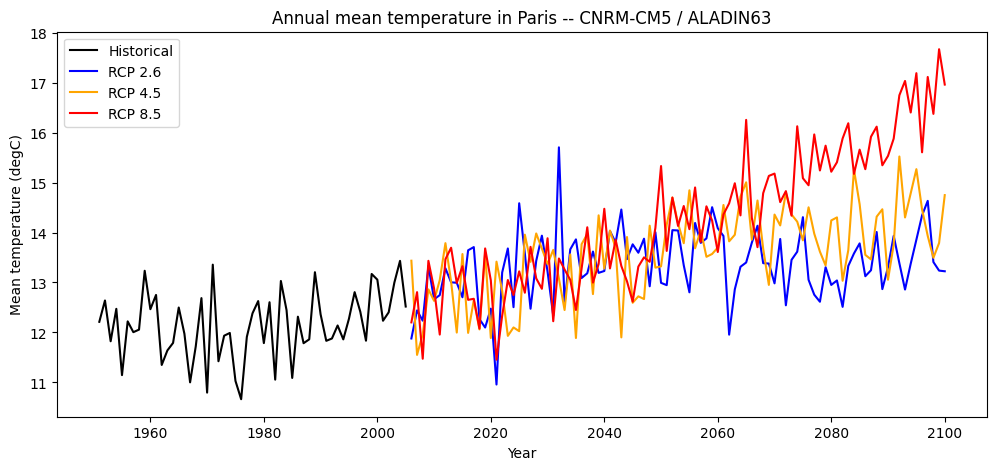

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(annual_hist['year'],  annual_hist['tas_c'],  color="black",  label="Historical")
plt.plot(annual_rcp26['year'],  annual_rcp26['tas_c'],  color="blue",  label="RCP 2.6")
plt.plot(annual_rcp45['year'],  annual_rcp45['tas_c'],  color="orange",  label="RCP 4.5")
plt.plot(annual_rcp85['year'],  annual_rcp85['tas_c'],  color="red",  label="RCP 8.5")
plt.xlabel("Year")
plt.ylabel("Mean temperature (degC)")
plt.title("Annual mean temperature in Paris -- CNRM-CM5 / ALADIN63")
plt.legend()
plt.show()


### 3.4 - Annual precipitation per scenario

Compute the annual mean daily precipitation for each dataset with `groupby("year")["precip_mm"].mean()`.

Plot all four scenarios on a single chart.

> **Observation:** Is the precipitation trend as clear as the temperature trend? Why might that be?

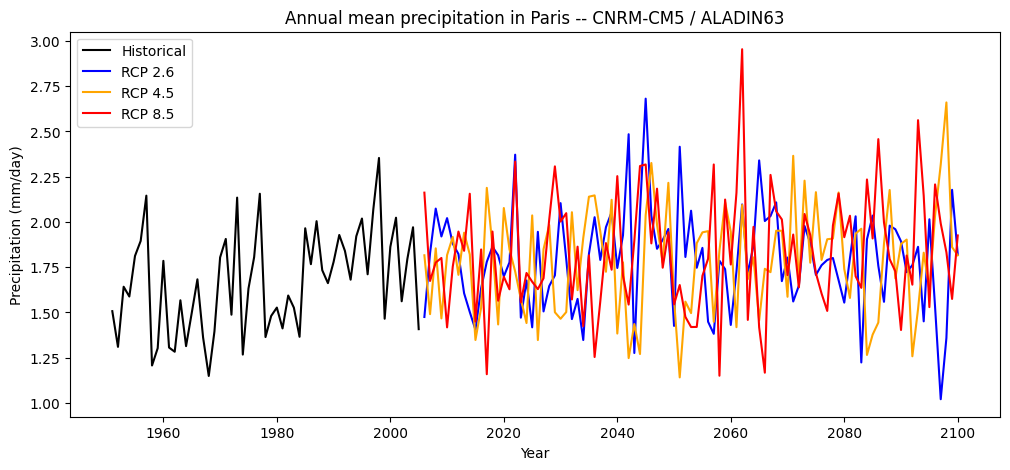

In [11]:
annual_pr_hist  = df_hist.groupby("year")["precip_mm"].mean().reset_index()
annual_pr_rcp26 = df_rcp26.groupby("year")["precip_mm"].mean().reset_index()
annual_pr_rcp45 = df_rcp45.groupby("year")["precip_mm"].mean().reset_index()
annual_pr_rcp85 = df_rcp85.groupby("year")["precip_mm"].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(annual_pr_hist['year'],  annual_pr_hist["precip_mm"],  color="black",  label="Historical")
plt.plot(annual_pr_rcp26['year'], annual_pr_rcp26["precip_mm"], color="blue",   label="RCP 2.6")
plt.plot(annual_pr_rcp45['year'], annual_pr_rcp45["precip_mm"], color="orange", label="RCP 4.5")
plt.plot(annual_pr_rcp85['year'], annual_pr_rcp85["precip_mm"], color="red",    label="RCP 8.5")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm/day)")
plt.title("Annual mean precipitation in Paris -- CNRM-CM5 / ALADIN63")
plt.legend()
plt.show()


### 3.5 - Smoothed precipitation (rolling average)

The annual series is noisy. Apply a **10-year centred rolling average** to each series to reduce noise:

```python
smoothed = annual_series.rolling(window=10, center=True).mean()
```

Replot the smoothed series. Do the scenarios diverge more clearly now?

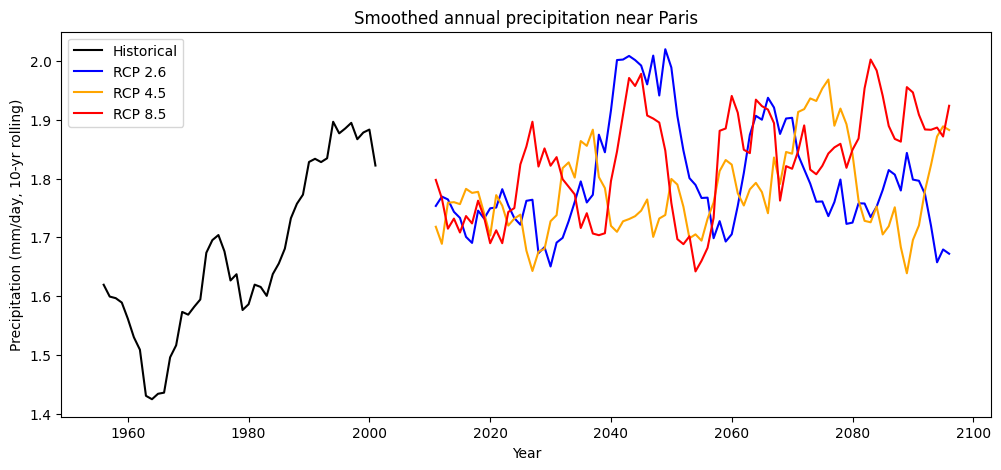

In [12]:
annual_pr_hist_s  = df_hist.groupby("year")["precip_mm"].mean().rolling(10, center=True).mean()
annual_pr_rcp26_s = df_rcp26.groupby("year")["precip_mm"].mean().rolling(10, center=True).mean()
annual_pr_rcp45_s = df_rcp45.groupby("year")["precip_mm"].mean().rolling(10, center=True).mean()
annual_pr_rcp85_s = df_rcp85.groupby("year")["precip_mm"].mean().rolling(10, center=True).mean()

plt.figure(figsize=(12, 5))
plt.plot(annual_pr_hist_s.index,  annual_pr_hist_s.values,  color="black",  label="Historical")
plt.plot(annual_pr_rcp26_s.index, annual_pr_rcp26_s.values, color="blue",   label="RCP 2.6")
plt.plot(annual_pr_rcp45_s.index, annual_pr_rcp45_s.values, color="orange", label="RCP 4.5")
plt.plot(annual_pr_rcp85_s.index, annual_pr_rcp85_s.values, color="red",    label="RCP 8.5")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm/day, 10-yr rolling)")
plt.title("Smoothed annual precipitation near Paris")
plt.legend()
plt.show()

### 3.6 - 20-year smoothed temperature: filtering natural variability

Annual temperature values jump year to year due to **natural climate variability** — random fluctuations driven by atmospheric dynamics, ocean circulation, volcanic eruptions, etc. This noise can mask the underlying long-term **anthropogenic signal**.

To reveal the forced trend, climate scientists apply a long rolling average (typically **20 years**, following IPCC climate normal conventions). Another classic approach is to average across many different climate models: since each model has its own random variability, it cancels out in the ensemble mean.

In our case, apply a **20-year centred rolling average** to the annual mean temperature series and replot all scenarios. I gave you an example for the historical data, do the same with the projections

> Does the divergence between RCP 8.5 and RCP 2.6 stand out more clearly now?

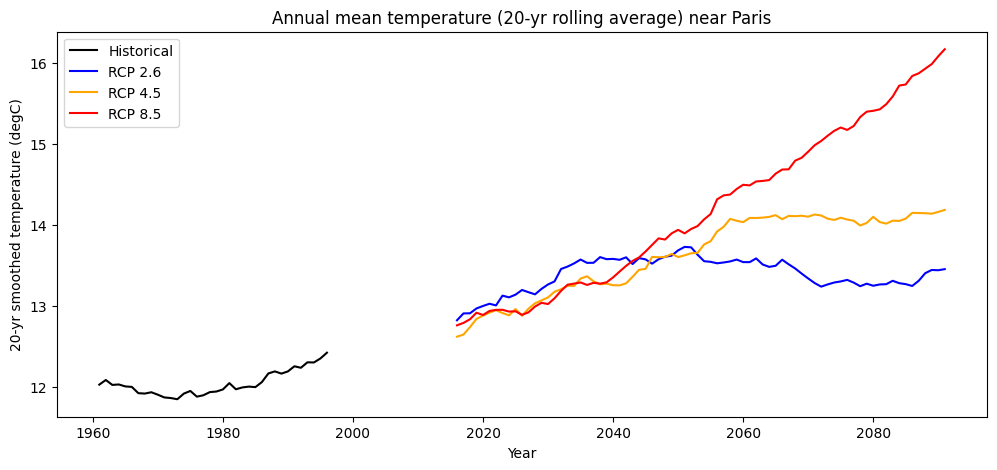

In [13]:
annual_hist_smooth  = annual_hist.set_index("year")["tas_c"].rolling(20, center=True).mean()
annual_rcp26_smooth = annual_rcp26.set_index("year")["tas_c"].rolling(20, center=True).mean()
annual_rcp45_smooth = annual_rcp45.set_index("year")["tas_c"].rolling(20, center=True).mean()
annual_rcp85_smooth = annual_rcp85.set_index("year")["tas_c"].rolling(20, center=True).mean()

plt.figure(figsize=(12, 5))
plt.plot(annual_hist_smooth.index,  annual_hist_smooth.values,  color="black",  label="Historical")
plt.plot(annual_rcp26_smooth.index, annual_rcp26_smooth.values, color="blue",   label="RCP 2.6")
plt.plot(annual_rcp45_smooth.index, annual_rcp45_smooth.values, color="orange", label="RCP 4.5")
plt.plot(annual_rcp85_smooth.index, annual_rcp85_smooth.values, color="red",    label="RCP 8.5")
plt.xlabel("Year")
plt.ylabel("20-yr smoothed temperature (degC)")
plt.title("Annual mean temperature (20-yr rolling average) near Paris")
plt.legend()
plt.show()

### 3.7 - Annual maximum temperature

Instead of the yearly mean, look at the **highest temperature recorded each year** (the annual maximum of `tasmax_c`). This captures how extreme the hottest days are becoming.

Use `groupby("year")["tasmax_c"].max()` for each dataset.

> How does the annual maximum evolve across scenarios compared with the mean?

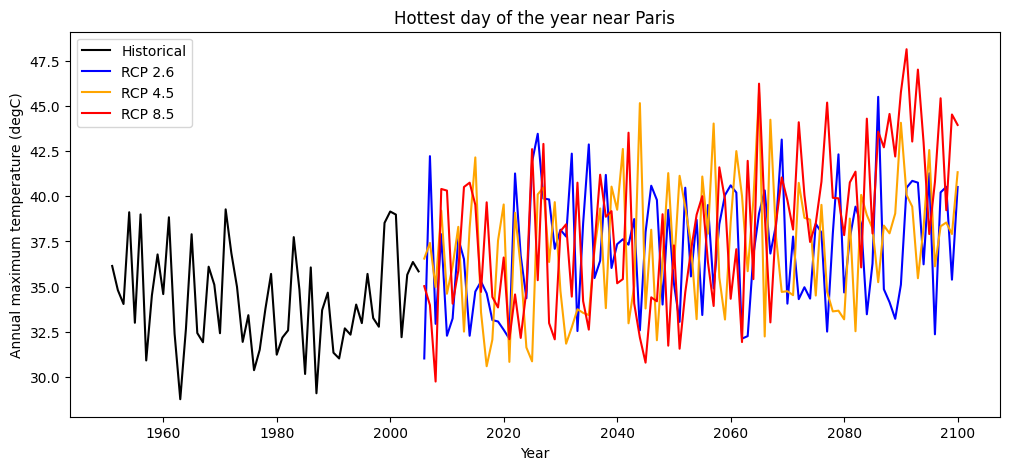

In [14]:
tmax_hist  = df_hist.groupby("year")["tasmax_c"].max()
tmax_rcp26 = df_rcp26.groupby("year")["tasmax_c"].max()
tmax_rcp45 = df_rcp45.groupby("year")["tasmax_c"].max()
tmax_rcp85 = df_rcp85.groupby("year")["tasmax_c"].max()

plt.figure(figsize=(12, 5))
plt.plot(tmax_hist.index,  tmax_hist.values,  color="black",  label="Historical")
plt.plot(tmax_rcp26.index, tmax_rcp26.values, color="blue",   label="RCP 2.6")
plt.plot(tmax_rcp45.index, tmax_rcp45.values, color="orange", label="RCP 4.5")
plt.plot(tmax_rcp85.index, tmax_rcp85.values, color="red",    label="RCP 8.5")
plt.xlabel("Year")
plt.ylabel("Annual maximum temperature (degC)")
plt.title("Hottest day of the year near Paris")
plt.legend()
plt.show()

---
## Part 4 - Climate Indicators

Rather than annual means, climate scientists focus on **extreme events**.

### 4.1 - Hot days (tasmax > 30 degC)

A **hot day** is a day where the daily maximum temperature exceeds 30 degC.

Create a boolean column `hot_day` in `df_hist` and count how many hot days there were per year on average.


In [15]:
df_hist["hot_day"] = df_hist["tasmax_c"] > 30

hot_days_hist = df_hist.groupby("year")["hot_day"].sum().reset_index()
print("Average hot days per year (historical):", hot_days_hist.mean().round(1))


Average hot days per year (historical): year       1978.0
hot_day      10.1
dtype: float64


### 4.2 - Hot days in each scenario

Do the same for the three RCP scenarios and plot how the number of hot days evolves over time.


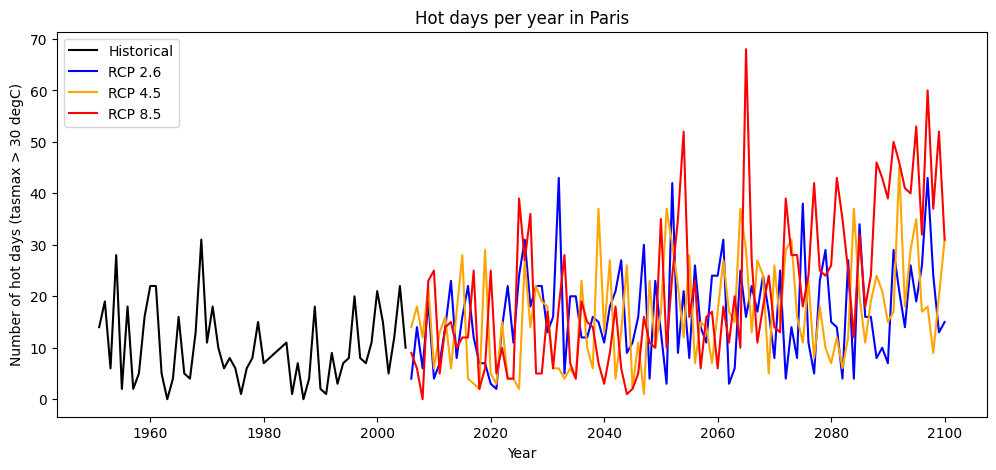

In [16]:
for df in [df_rcp26, df_rcp45, df_rcp85]:
    df["hot_day"] = df["tasmax_c"] > 30

hot_days_rcp26 = df_rcp26.groupby("year")["hot_day"].sum().reset_index()
hot_days_rcp45 = df_rcp45.groupby("year")["hot_day"].sum().reset_index()
hot_days_rcp85 = df_rcp85.groupby("year")["hot_day"].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(hot_days_hist.year,  hot_days_hist.hot_day,  color="black",  label="Historical")
plt.plot(hot_days_rcp26.year, hot_days_rcp26.hot_day, color="blue",   label="RCP 2.6")
plt.plot(hot_days_rcp45.year, hot_days_rcp45.hot_day, color="orange", label="RCP 4.5")
plt.plot(hot_days_rcp85.year, hot_days_rcp85.hot_day, color="red",    label="RCP 8.5")
plt.xlabel("Year")
plt.ylabel("Number of hot days (tasmax > 30 degC)")
plt.title("Hot days per year in Paris")
plt.legend()
plt.show()


### 4.3 - Warm nights (tasmin > 20 degC)

A **warm night** is a night where the minimum temperature stays above 20 degC.
These are particularly uncomfortable in cities and can affect health.

Count the number of warm nights per year for each scenario and plot the result.


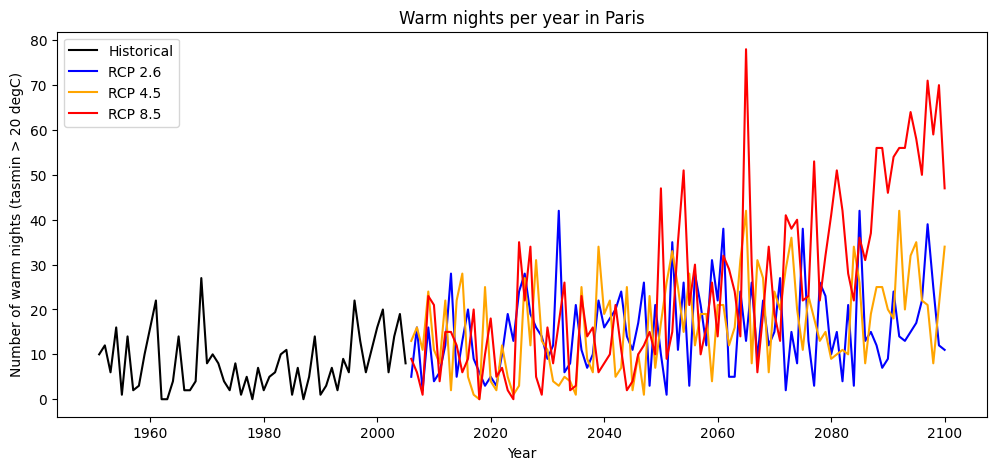

In [17]:
for df in [df_hist, df_rcp26, df_rcp45, df_rcp85]:
    df["warm_night"] = df["tasmin_c"] > 20

warm_hist  = df_hist.groupby("year")["warm_night"].sum().reset_index()
warm_rcp26 = df_rcp26.groupby("year")["warm_night"].sum().reset_index()
warm_rcp45 = df_rcp45.groupby("year")["warm_night"].sum().reset_index()
warm_rcp85 = df_rcp85.groupby("year")["warm_night"].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(warm_hist.year,  warm_hist.warm_night,  color="black",  label="Historical")
plt.plot(warm_rcp26.year, warm_rcp26.warm_night, color="blue",   label="RCP 2.6")
plt.plot(warm_rcp45.year, warm_rcp45.warm_night, color="orange", label="RCP 4.5")
plt.plot(warm_rcp85.year, warm_rcp85.warm_night, color="red",    label="RCP 8.5")
plt.xlabel("Year")
plt.ylabel("Number of warm nights (tasmin > 20 degC)")
plt.title("Warm nights per year in Paris")
plt.legend()
plt.show()


### 4.4 - Snow days (supplementary)

The `prsn` variable gives **solid precipitation** (snow + sleet) in kg/m²/s.
Convert it to mm/day (× 86400), then define a **snow day** as any day with solid precipitation above **1 mm/day**.

Count the number of snow days per year for each scenario and plot the result.

> Does snow nearly disappear near Paris under RCP 8.5 by the end of the century?

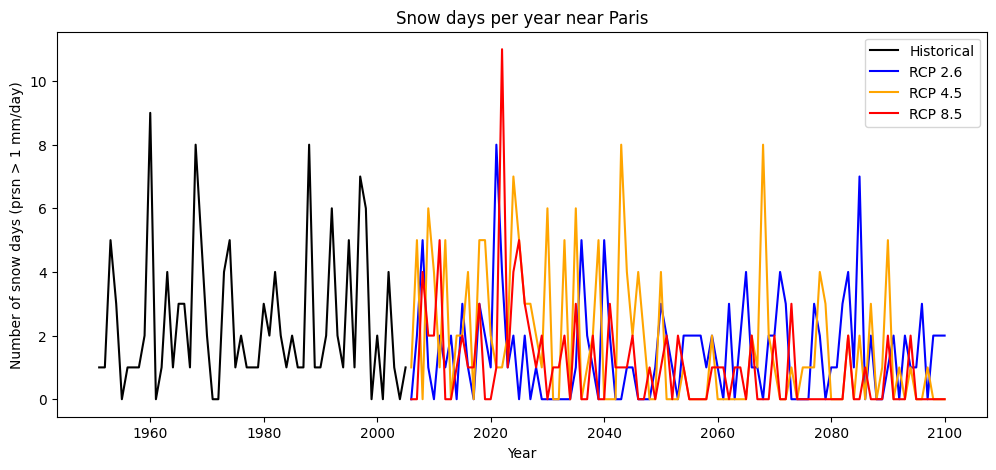

In [18]:
for df in [df_hist, df_rcp26, df_rcp45, df_rcp85]:
    df["prsn_mm"]  = df["prsn"] * 86400
    df["snow_day"] = df["prsn_mm"] > 1
    

snow_hist  = df_hist.groupby("year")["snow_day"].sum().reset_index()
snow_rcp26 = df_rcp26.groupby("year")["snow_day"].sum().reset_index()
snow_rcp45 = df_rcp45.groupby("year")["snow_day"].sum().reset_index()
snow_rcp85 = df_rcp85.groupby("year")["snow_day"].sum().reset_index()


plt.figure(figsize=(12, 5))
plt.plot(snow_hist.year,  snow_hist.snow_day,  color="black",  label="Historical")
plt.plot(snow_rcp26.year, snow_rcp26.snow_day, color="blue",   label="RCP 2.6")
plt.plot(snow_rcp45.year, snow_rcp45.snow_day, color="orange", label="RCP 4.5")
plt.plot(snow_rcp85.year, snow_rcp85.snow_day, color="red",    label="RCP 8.5")
plt.xlabel("Year")
plt.ylabel("Number of snow days (prsn > 1 mm/day)")
plt.title("Snow days per year near Paris")
plt.legend()
plt.show()

### 4.5 - Smoothed snow days (rolling average)

The annual snow signal is also noisy. Apply a **10-year centred rolling average** to the snow day series to reveal the long-term trend.

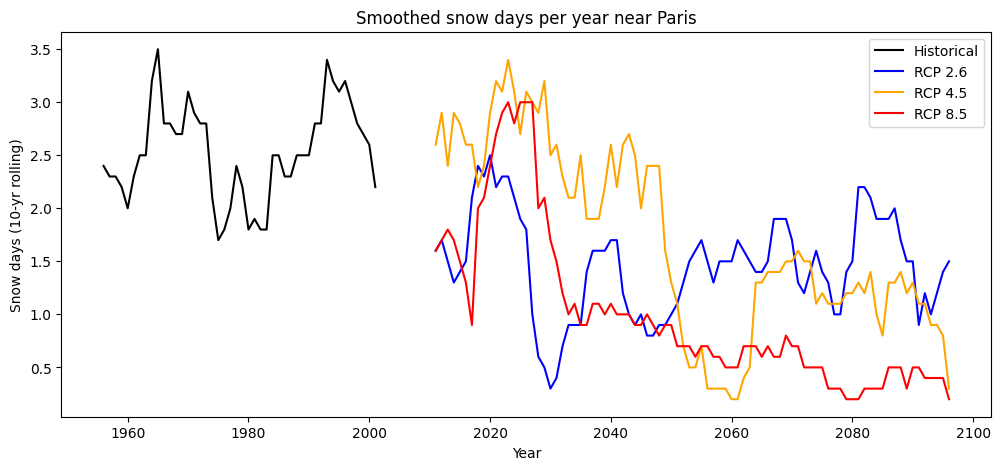

In [23]:

snow_hist  = df_hist.groupby("year")["snow_day"].sum().reset_index()
snow_rcp26 = df_rcp26.groupby("year")["snow_day"].sum().reset_index()
snow_rcp45 = df_rcp45.groupby("year")["snow_day"].sum().reset_index()
snow_rcp85 = df_rcp85.groupby("year")["snow_day"].sum().reset_index()

snow_hist_s  = snow_hist.set_index("year").rolling(10, center=True).mean()
snow_rcp26_s = snow_rcp26.set_index("year").rolling(10, center=True).mean()
snow_rcp45_s = snow_rcp45.set_index("year").rolling(10, center=True).mean()
snow_rcp85_s = snow_rcp85.set_index("year").rolling(10, center=True).mean()

plt.figure(figsize=(12, 5))
plt.plot(snow_hist_s.index,  snow_hist_s.values,  color="black",  label="Historical")
plt.plot(snow_rcp26_s.index, snow_rcp26_s.values, color="blue",   label="RCP 2.6")
plt.plot(snow_rcp45_s.index, snow_rcp45_s.values, color="orange", label="RCP 4.5")
plt.plot(snow_rcp85_s.index, snow_rcp85_s.values, color="red",    label="RCP 8.5")
plt.xlabel("Year")
plt.ylabel("Snow days (10-yr rolling)")
plt.title("Smoothed snow days per year near Paris")
plt.legend()
plt.show()

---
## Part 5 - Quantifying Change: Reference Period vs. Future

To measure how much the climate changes, scientists compare a **future period** to a **reference period**.

We will use:
- **Reference**: 1986-2005 (IPCC AR5 baseline period)
- **Near future**: 2021-2050 (projections)
- **Far future**: 2071-2100 (projections)

### 5.1 - Reference mean temperature (1986-2005)

Filter `df_hist` to keep only years 1986-2005, then compute the mean of `tas_c`.

In [20]:
df_ref = df_hist[(df_hist["year"] >= 1986) & (df_hist["year"] <= 2005)]
ref_mean_temp = df_ref["tas_c"].mean()

print("Reference mean temperature (1986-2005):", ref_mean_temp.round(2), "degC")


Reference mean temperature (1986-2005): 12.42 degC


### 5.2 - Future mean temperatures

Compute the mean temperature for 2021-2050 and 2071-2100 for each scenario.

Tip: write a helper function to avoid repeating the same code:

```python
def period_mean(df, start, end):
    mask = (df["year"] >= start) & (df["year"] <= end)
    return df[mask]["tas_c"].mean()
```


In [21]:
def period_mean(df, start, end):
    mask = (df["year"] >= start) & (df["year"] <= end)
    return df[mask]["tas_c"].mean()

near_future = {
    "RCP 2.6": period_mean(df_rcp26, 2021, 2040),
    "RCP 4.5": period_mean(df_rcp45, 2021, 2040),
    "RCP 8.5": period_mean(df_rcp85, 2021, 2040),
}

far_future = {
    "RCP 2.6": period_mean(df_rcp26, 2081, 2100),
    "RCP 4.5": period_mean(df_rcp45, 2081, 2100),
    "RCP 8.5": period_mean(df_rcp85, 2081, 2100),
}

print("Near future (2021-2050):", {k: round(v, 2) for k, v in near_future.items()})
print("Far future  (2071-2100):", {k: round(v, 2) for k, v in far_future.items()})


Near future (2021-2050): {'RCP 2.6': np.float64(13.3), 'RCP 4.5': np.float64(13.17), 'RCP 8.5': np.float64(13.09)}
Far future  (2071-2100): {'RCP 2.6': np.float64(13.45), 'RCP 4.5': np.float64(14.19), 'RCP 8.5': np.float64(16.17)}


### 5.3 - Compute the warming (delta T)

Subtract the reference mean temperature from each future value to get the temperature **change**.


In [102]:
delta_near = {s: v - ref_mean_temp for s, v in near_future.items()}
delta_far  = {s: v - ref_mean_temp for s, v in far_future.items()}

print("Warming 2021-2050:", {k: round(v, 2) for k, v in delta_near.items()})
print("Warming 2071-2100:", {k: round(v, 2) for k, v in delta_far.items()})


Warming 2021-2050: {'RCP 2.6': np.float64(0.88), 'RCP 4.5': np.float64(0.75), 'RCP 8.5': np.float64(0.67)}
Warming 2071-2100: {'RCP 2.6': np.float64(1.03), 'RCP 4.5': np.float64(1.77), 'RCP 8.5': np.float64(3.75)}


### 5.4 - Bar chart of future warming

Create a grouped bar chart showing the warming for both the near and far future, per scenario.

Use `numpy` to place bars side by side:

```python
import numpy as np
x = np.arange(len(scenarios))   # [0, 1, 2]
width = 0.35
plt.bar(x - width/2, list(delta_near.values()), width, label="2021-2050")
plt.bar(x + width/2, list(delta_far.values()),  width, label="2071-2100")
plt.xticks(x, scenarios)
```


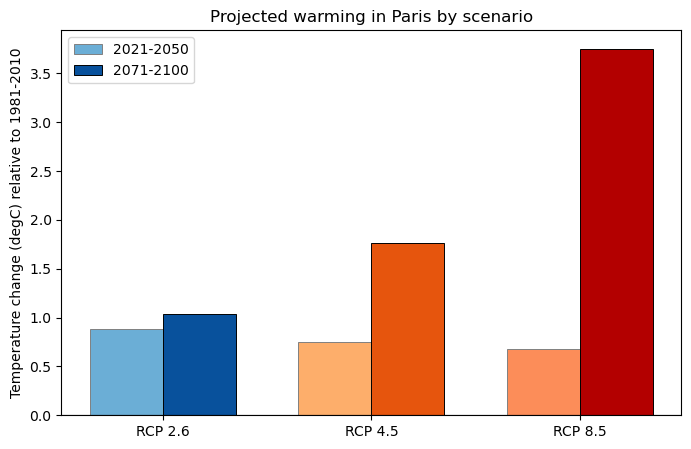

In [103]:
import numpy as np

scenarios = list(delta_near.keys())
x = np.arange(len(scenarios))
width = 0.35

colors_near = ["#6baed6", "#fdae6b", "#fc8d59"]   # muted blue / orange / red (near future)
colors_far  = ["#08519c", "#e6550d", "#b30000"]   # deep  blue / orange / red (far future)

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, list(delta_near.values()), width, label="2021-2050",
        color=colors_near, edgecolor="grey",  linewidth=0.7)
plt.bar(x + width/2, list(delta_far.values()),  width, label="2071-2100",
        color=colors_far,  edgecolor="black", linewidth=0.7)
plt.xticks(x, scenarios)
plt.ylabel("Temperature change (degC) relative to 1981-2010")
plt.title("Projected warming in Paris by scenario")
plt.legend()
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

---
## Going Further — Explore DRIAS

This TD uses a **single climate model** (CNRM-CM5) at a **single location** (near Paris). Real climate assessments always rely on **ensembles** of many models: the spread across models captures the remaining uncertainty in climate projections, and averaging across them reduces the influence of each model's internal variability.

**DRIAS** (drias-les-futurs.fr) is the French national portal for regional climate projections. It gives access to:
- Several regional climate models
- All RCP scenarios
- Any location in metropolitan France (point or region)

**To pursue:** Download data for a different city (e.g. **Marseille**, **Lyon**, or **Toulouse**) or a different model, and redo some of the analyses above.

Things to investigate:
- Does RCP 8.5 still show the strongest warming everywhere?
- Does a coastal city warm differently from an inland city?
- Do hot days increase by the same amount in southern France as in Paris?

---
## Congratulations!

You have completed TD3. You have learned how to:
- Load climate data from CSV files
- Convert physical units (K to degC, kg/m²/s to mm/day)
- Compare multiple emission scenarios on the same chart
- Filter natural variability with rolling averages
- Compute climate indicators (hot days, warm nights, snow days)
- Quantify future warming relative to a reference period
